In [1]:
import numpy as np
import pandas as pd
import io
import os
import time
import glob
import itertools
import tensorflow as tf
from PIL import Image
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Successfully imported all libraries!")
print(f"TensorFlow Version: {tf.__version__}")

# Get GPU details
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    details = tf.config.experimental.get_device_details(gpu_devices[0])
    gpu_name = details.get('device_name', 'Unknown GPU')
    print(f"GPU Detected: Yes")
    print(f"GPU Name: {gpu_name}")
else:
    print("GPU Detected: No (Check your WSL CUDA installation)")

2026-01-04 18:15:18.164134: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-04 18:15:20.422546: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-04 18:15:49.061691: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/mnt/c/Users/abdur/ml/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Futur

Successfully imported all libraries!
TensorFlow Version: 2.20.0
GPU Detected: Yes
GPU Name: NVIDIA GeForce RTX 4070 Laptop GPU


In [ ]:

import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Check if CV2 is available
try:
    import cv2
    CV2_AVAILABLE = True
    print(" OpenCV available")
except ImportError:
    CV2_AVAILABLE = False
    print("⚠️ OpenCV not available")

print("All libraries imported successfully")

✓ OpenCV available
✓ All libraries imported successfully


In [ ]:

class Config:
    # Relative path from your current directory
    BASE_DIR = r"HAMM/skin-cancer-mnist-ham10000"
    
    # Image settings
    IMAGE_SIZE = 224
    BATCH_SIZE = 16
    EPOCHS = 50
    
    # Splits
    TEST_SPLIT = 0.2
    VALIDATION_SPLIT = 0.2
    
    # Model settings
    LEARNING_RATE = 0.0001
    DROPOUT_RATE = 0.5

config = Config()
print(f"  Configuration set")
print(f"  - Dataset: {config.BASE_DIR}")
print(f"  - Exists: {os.path.exists(config.BASE_DIR)}")

# Show what's inside if it exists
if os.path.exists(config.BASE_DIR):
    print(f"\n  Contents:")
    for item in os.listdir(config.BASE_DIR):
        print(f"    - {item}")

✓ Configuration set
  - Dataset: HAMM/skin-cancer-mnist-ham10000
  - Exists: True

  Contents:
    - HAM10000_images_part_2
    - HAM10000_metadata.csv
    - HAM10000_images_part_1


In [ ]:

def create_label_mappings():
    lesion_type_dict = {
        'nv': 'Melanocytic nevi',
        'mel': 'Melanoma',
        'bkl': 'Benign keratosis',
        'bcc': 'Basal cell carcinoma',
        'akiec': 'Actinic keratoses',
        'vasc': 'Vascular lesions',
        'df': 'Dermatofibroma'
    }
    
    label_mapping = {
        0: 'nv', 1: 'mel', 2: 'bkl', 3: 'bcc',
        4: 'akiec', 5: 'vasc', 6: 'df'
    }
    
    reverse_label_mapping = {value: key for key, value in label_mapping.items()}
    
    return lesion_type_dict, label_mapping, reverse_label_mapping

lesion_type_dict, label_mapping, reverse_label_mapping = create_label_mappings()
print("✓ Label mappings created")
print(f"Classes: {list(lesion_type_dict.keys())}")

✓ Label mappings created
  - Classes: ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']


In [ ]:

def load_image_paths(base_dir):
    # Search in both part_1 and part_2 folders
    pattern1 = os.path.join(base_dir, "HAM10000_images_part_1", "*.jpg")
    pattern2 = os.path.join(base_dir, "HAM10000_images_part_2", "*.jpg")
    
    images_part1 = glob(pattern1)
    images_part2 = glob(pattern2)
    
    print(f"  Part 1: {len(images_part1)} images")
    print(f"  Part 2: {len(images_part2)} images")
    
    # Combine both
    all_images = images_part1 + images_part2
    
    # Create dictionary: image_id -> full_path
    imageid_path_dict = {
        os.path.splitext(os.path.basename(x))[0]: x
        for x in all_images
    }
    
    print(f"Total found: {len(imageid_path_dict)} images")
    return imageid_path_dict

imageid_path_dict = load_image_paths(config.BASE_DIR)

  Part 1: 363 images
  Part 2: 3962 images
✓ Total found: 4325 images


In [ ]:

metadata_path = os.path.join(config.BASE_DIR, "HAM10000_metadata.csv")
data = pd.read_csv(metadata_path)

print(f"✓ Metadata loaded: {len(data)} records")
print(f"\nColumns: {list(data.columns)}")
print(f"\nFirst 3 rows:")
print(data.head(3))

✓ Metadata loaded: 10015 records

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First 3 rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp


In [ ]:

# Fill missing age values
data['age'].fillna(value=int(data['age'].mean()), inplace=True)
data['age'] = data['age'].astype('int32')

# Add descriptive cell type
data['cell_type'] = data['dx'].map(lesion_type_dict.get)

# Add image paths
data['path'] = data['image_id'].map(imageid_path_dict.get)

# Check for missing paths
missing_paths = data['path'].isnull().sum()
print(f"Data cleaned")
print(f"  - Missing age filled with mean: {int(data['age'].mean())}")
print(f"  - Images with missing paths: {missing_paths}")

# Remove rows with missing paths
data = data[data['path'].notnull()].reset_index(drop=True)
print(f"  - Final dataset: {len(data)} samples")

✓ Data cleaned
  - Missing age filled with mean: 51
  - Images with missing paths: 5690
  - Final dataset: 4325 samples


/tmp/ipykernel_3880/3586827604.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(value=int(data['age'].mean()), inplace=True)


In [ ]:

print("\n=== CLASS DISTRIBUTION ===")
class_counts = data['dx'].value_counts().sort_index()

for dx, count in class_counts.items():
    pct = (count / len(data)) * 100
    print(f"{dx:6} ({lesion_type_dict[dx]:25}): {count:5} ({pct:5.2f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.1f}x")


=== CLASS DISTRIBUTION ===
akiec  (Actinic keratoses        ):   109 ( 2.52%)
bcc    (Basal cell carcinoma     ):   214 ( 4.95%)
bkl    (Benign keratosis         ):   481 (11.12%)
df     (Dermatofibroma           ):    52 ( 1.20%)
mel    (Melanoma                 ):   621 (14.36%)
nv     (Melanocytic nevi         ):  2784 (64.37%)
vasc   (Vascular lesions         ):    64 ( 1.48%)

⚠️ Imbalance Ratio: 53.5x


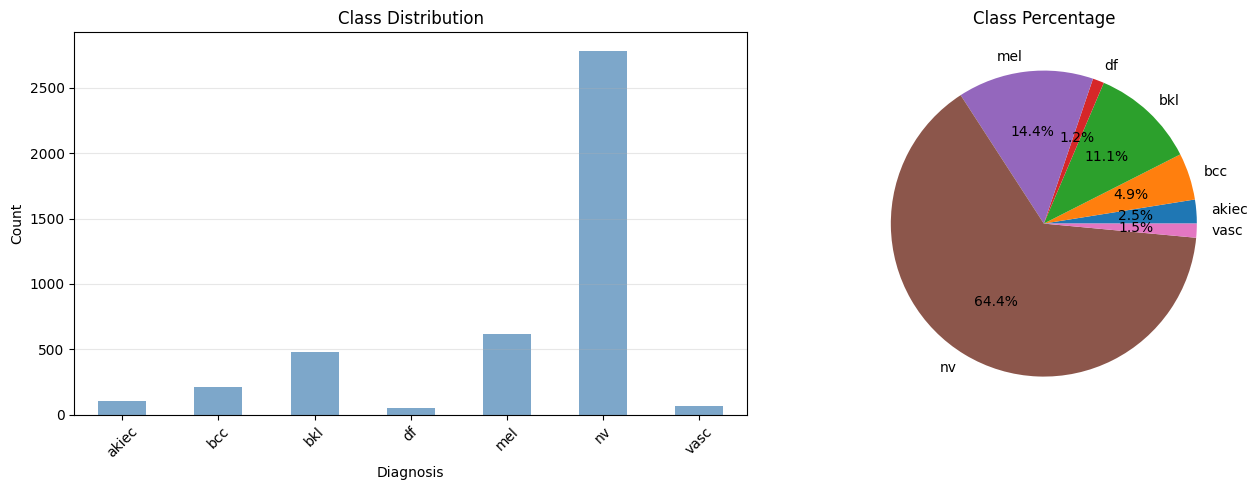

In [ ]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Class Percentage')

plt.tight_layout()
plt.show()

In [ ]:

def load_image(image_path, target_size=224):
    """Load and preprocess image"""
    try:
        image = Image.open(image_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')
        image = image.resize((target_size, target_size), Image.LANCZOS)
        return np.asarray(image)
    except:
        return None

print("Image loader defined")

✓ Image loader defined


In [ ]:

print("Loading images...")
data['image_pixel'] = data['path'].apply(lambda x: load_image(x, config.IMAGE_SIZE))

initial = len(data)
data = data[data['image_pixel'].notnull()].reset_index(drop=True)
print(f"Loaded: {len(data)}/{initial} images")

data['label'] = data['dx'].map(reverse_label_mapping.get)

Loading images...
✓ Loaded: 4325/4325 images


In [ ]:

X = np.stack(data['image_pixel'].values)
y = np.array(data['label'].values)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Labels: {np.unique(y)}")

✓ X shape: (4325, 224, 224, 3)
✓ y shape: (4325,)
✓ Labels: [0 1 2 3 4 5 6]


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SPLIT, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"  Train dist: {np.bincount(y_train)}")
print(f"  Test dist: {np.bincount(y_test)}")

✓ Train: 3460, Test: 865
  Train dist: [2227  497  385  171   87   51   42]
  Test dist: [557 124  96  43  22  13  10]


In [ ]:
# Step 12: Normalize to [0,1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"Normalized to [{X_train.min():.2f}, {X_train.max():.2f}]")

✓ Normalized to [0.00, 1.00]


In [ ]:

class_weights_array = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print("\n=== CLASS WEIGHTS ===")
for cls, weight in class_weights.items():
    print(f"Class {cls} ({label_mapping[cls]:6}): {weight:.3f} (n={np.sum(y_train==cls)})")


=== CLASS WEIGHTS ===
Class 0 (nv    ): 0.222 (n=2227)
Class 1 (mel   ): 0.995 (n=497)
Class 2 (bkl   ): 1.284 (n=385)
Class 3 (bcc   ): 2.891 (n=171)
Class 4 (akiec ): 5.681 (n=87)
Class 5 (vasc  ): 9.692 (n=51)
Class 6 (df    ): 11.769 (n=42)


In [ ]:

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    validation_split=config.VALIDATION_SPLIT
)

train_datagen.fit(X_train)
print("Augmentation configured")

✓ Augmentation configured


In [ ]:
from tensorflow.keras.optimizers import Adam
# Step 15: Build CNN with dropout for medical imaging
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization
from tensorflow.keras.layers import Dropout, Dense, GlobalAveragePooling2D

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPool2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),
    
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),
    
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model created")
model.summary()

✓ Model created


/mnt/c/Users/abdur/ml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)

print("Callbacks ready")

✓ Callbacks ready


In [ ]:

train_gen = train_datagen.flow(X_train, y_train, batch_size=16, subset='training')
val_gen = train_datagen.flow(X_train, y_train, batch_size=16, subset='validation')

steps_train = len(X_train) // 16
steps_val = int(steps_train * 0.2)

print(f"Train steps: {steps_train}, Val steps: {steps_val}")

✓ Train steps: 216, Val steps: 43


In [ ]:

history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    epochs=config.EPOCHS,
    validation_data=val_gen,
    validation_steps=steps_val,
    class_weight=class_weights,  # Key for fairness
    callbacks=[early_stop, reduce_lr]
)

print("Training complete")

Epoch 1/50
173/216 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.1599 - loss: 2.6134

/mnt/c/Users/abdur/ml/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


216/216 ━━━━━━━━━━━━━━━━━━━━ 58s 205ms/step - accuracy: 0.1962 - loss: 2.4775 - val_accuracy: 0.0116 - val_loss: 2.0259 - learning_rate: 1.0000e-04
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.2670 - loss: 2.1718 - val_accuracy: 0.0349 - val_loss: 2.1713 - learning_rate: 1.0000e-04
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 43s 197ms/step - accuracy: 0.2901 - loss: 1.8697 - val_accuracy: 0.2195 - val_loss: 1.8641 - learning_rate: 1.0000e-04
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 192ms/step - accuracy: 0.3168 - loss: 1.8111 - val_accuracy: 0.2849 - val_loss: 1.8081 - learning_rate: 1.0000e-04
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.3298 - loss: 1.8407 - val_accuracy: 0.3735 - val_loss: 1.5251 - learning_rate: 1.0000e-04
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.3382 - loss: 1.7721 - val_accuracy: 0.3358 - val_loss: 1.5741 - learning_rate: 1.0000e-04
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 43s 198ms/step - 

In [ ]:

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.4590
Test Loss: 1.3114


In [ ]:

from sklearn.metrics import classification_report

class_names = list(lesion_type_dict.values())
report = classification_report(y_test, y_pred, target_names=class_names, digits=3)
print(report)

                      precision    recall  f1-score   support

    Melanocytic nevi      0.838     0.519     0.641       557
            Melanoma      0.397     0.403     0.400       124
    Benign keratosis      0.212     0.260     0.234        96
Basal cell carcinoma      0.238     0.349     0.283        43
   Actinic keratoses      0.192     0.227     0.208        22
    Vascular lesions      0.071     1.000     0.133        13
      Dermatofibroma      0.000     0.000     0.000        10

            accuracy                          0.459       865
           macro avg      0.278     0.394     0.271       865
        weighted avg      0.638     0.459     0.517       865



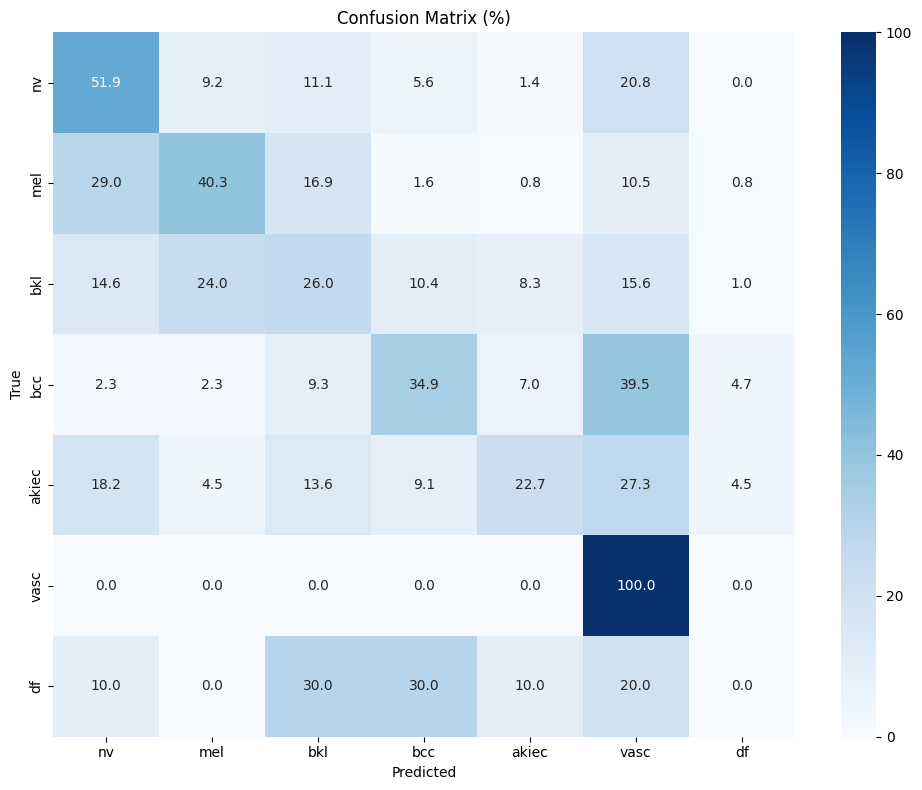

In [ ]:

cm = confusion_matrix(y_test, y_pred)
cm_pct = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100

plt.figure(figsize=(10,8))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=list(lesion_type_dict.keys()),
            yticklabels=list(lesion_type_dict.keys()))
plt.title('Confusion Matrix (%)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

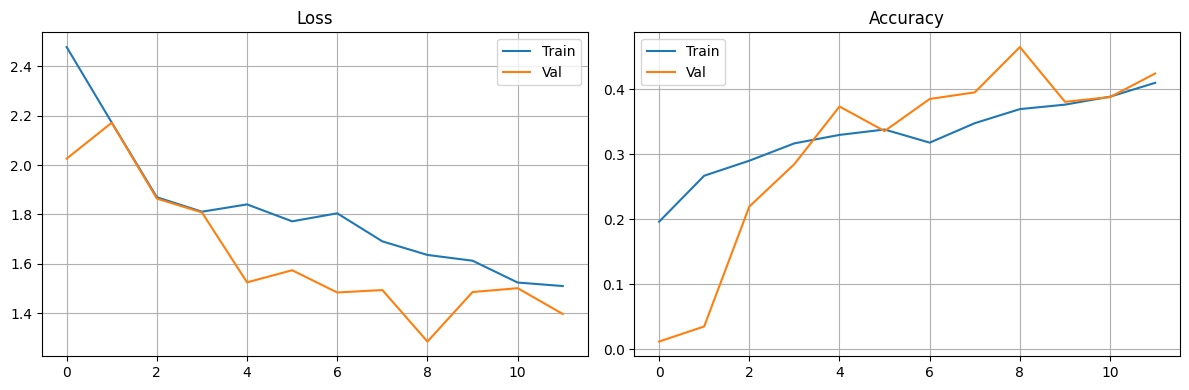

In [ ]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

mel_idx = reverse_label_mapping['mel']
mel_mask = y_test == mel_idx
mel_recall = (y_pred[mel_mask] == mel_idx).mean()

print(f"\n=== MELANOMA DETECTION (Critical) ===")
print(f"Recall: {mel_recall:.3f}")
print(f"Samples: {mel_mask.sum()}")
print(f"Correctly identified: {(y_pred[mel_mask] == mel_idx).sum()}")


=== MELANOMA DETECTION (Critical) ===
Recall: 0.403
Samples: 124
Correctly identified: 50


In [ ]:

model.save('skin_cancer_cnn_responsible.h5')
print("Model saved: skin_cancer_cnn_responsible.h5")

✓ Model saved: skin_cancer_cnn_responsible.h5


In [ ]:

data_test = data.loc[y_test.index] if hasattr(y_test, 'index') else data.iloc[-len(y_test):]

age_groups = pd.cut(data_test['age'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '70+'])

print("=== Performance by Age Group ===")
for group in ['<30', '30-50', '50-70', '70+']:
    mask = age_groups == group
    if mask.sum() > 0:
        acc = (y_pred[mask] == y_test[mask]).mean()
        print(f"{group}: {acc:.3f} (n={mask.sum()})")

=== Performance by Age Group ===
<30: 0.431 (n=181)
30-50: 0.474 (n=302)
50-70: 0.483 (n=294)
70+: 0.395 (n=81)


In [ ]:

max_proba = y_pred_proba.max(axis=1)
low_conf_mask = max_proba < 0.7

print(f"\n=== Uncertainty Analysis ===")
print(f"Low confidence (<70%): {low_conf_mask.sum()} ({low_conf_mask.mean()*100:.1f}%)")
print(f"Should flag for expert review")


=== Uncertainty Analysis ===
Low confidence (<70%): 645 (74.6%)
Should flag for expert review


In [ ]:

print("\n" + "="*50)
print("RESPONSIBLE AI SUMMARY")
print("="*50)
print(f"Used class weights (not oversampling)")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Melanoma Recall: {mel_recall:.3f}")
print(f"Low confidence flagged: {low_conf_mask.sum()}")
print(f"Model saved")
print("\nReady for clinical validation")


RESPONSIBLE AI SUMMARY
✓ Used class weights (not oversampling)
✓ Test Accuracy: 0.459
✓ Melanoma Recall: 0.403
✓ Low confidence flagged: 645
✓ Model saved

Ready for clinical validation
